<a href="https://colab.research.google.com/github/hwollwage/PCVK_2026/blob/main/week_05_15_244107020157.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob
from google.colab import drive
import sys, platform, hashlib, datetime, zoneinfo

In [13]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<BarContainer object of 256 artists>

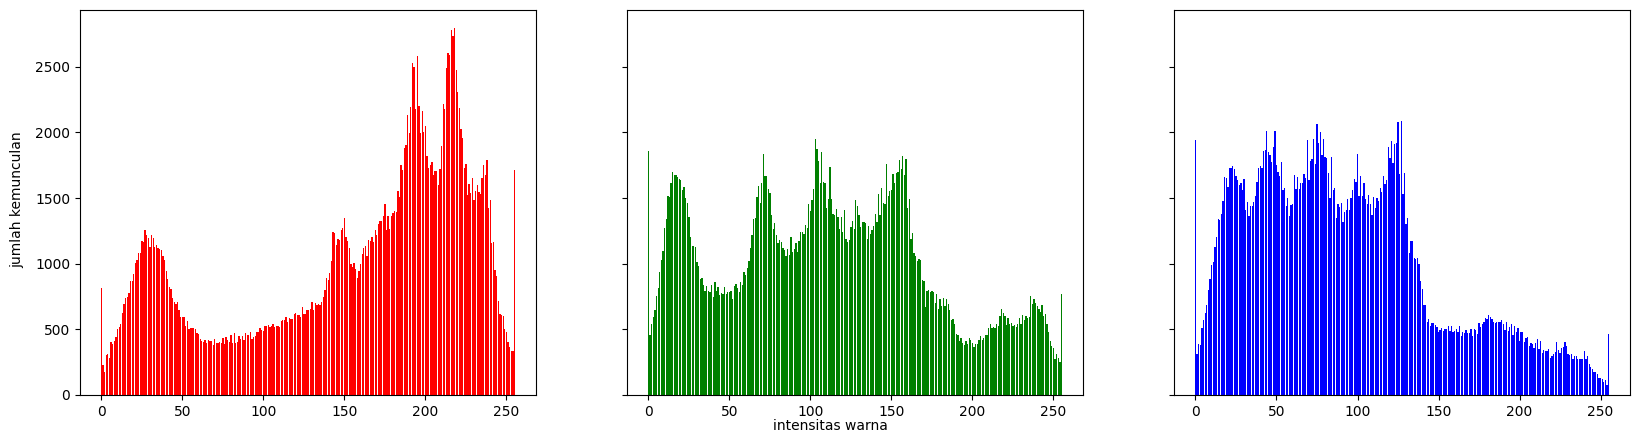

In [3]:
img = cv.imread('/content/drive/MyDrive/Colab Notebooks/gambar/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
h,w,d = np.shape(img)
red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0,h):
  for x in range(0,w):
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axes = plt.subplots(1,3, figsize=[20,5], sharex=True, sharey=True)
fig.text(0.09, 0.5, 'jumlah kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'intensitas warna', ha='center')
axes[0].bar(names, red, color='red')
axes[1].bar(names, green, color='green')
axes[2].bar(names, blue, color='blue')

In [28]:
NAMA = 'HANZEL PUTRA WOLLWAGE'
NIM = '244107020157'
CONTOH = '/content/drive/MyDrive/Colab Notebooks/gambar'
BASE = '/content/drive/MyDrive/Colab Notebooks/gambar/'+NIM
N = int(NIM[-3:])
PARAM = {
  'bins' : 2 ** ((N % 4) + 3),
  'clip' : round(1.0 + (N % 5) * 0.5, 1),
  'tile' : (N % 4) + 2,
  'L'    : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA: ', NAMA)
print('NIM: ', NIM)
for k, v in PARAM.items():
  print('%-6s : ' % k, v)

print('waktu: ', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('system: ', sys.version.split()[0], platform.platform())
kunci = NIM + '|'+ waktu.strftime('%Y-%m-%d')
print('token: ', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA:  HANZEL PUTRA WOLLWAGE
NIM:  244107020157
bins   :  16
clip   :  2.0
tile   :  3
L      :  4
waktu:  2026-09-30 10:38:01 WIB
system:  3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
token:  84b40d2d5c74d992


In [18]:
# E1-1
def histogram_manual(img, L=256):
  h = np.zeros(L, dtype=np.int64)
  for y in range(img.shape[0]):
    for x in range(img.shape[1]):
      h[img[y, x]] += 1
  return h

def bandingkan(path, nama):
  g = cv.imread(path, cv.IMREAD_GRAYSCALE)
  h_man = histogram_manual(g)
  h_np, _ = np.histogram(g, bins=256, range=(0, 256))
  h_cv = cv.calcHist([g], [0], None, [256], [0, 256]).flatten().astype(np.int64)
  assert h_man.sum() == g.size
  print(nama, '| manual-numpy:', np.abs(h_man - h_np).max(),'| manual-calcHist:', np.abs(h_man - h_cv).max(),'| numpy-calcHist:', np.abs(h_np - h_cv).max())

bandingkan(CONTOH + '/lena.jpg', 'lena.jpg')
bandingkan(BASE + '/KTM1b.jpg', 'KTM1b.jpg')

lena.jpg | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0
KTM1b.jpg | manual-numpy: 0 | manual-calcHist: 0 | numpy-calcHist: 0


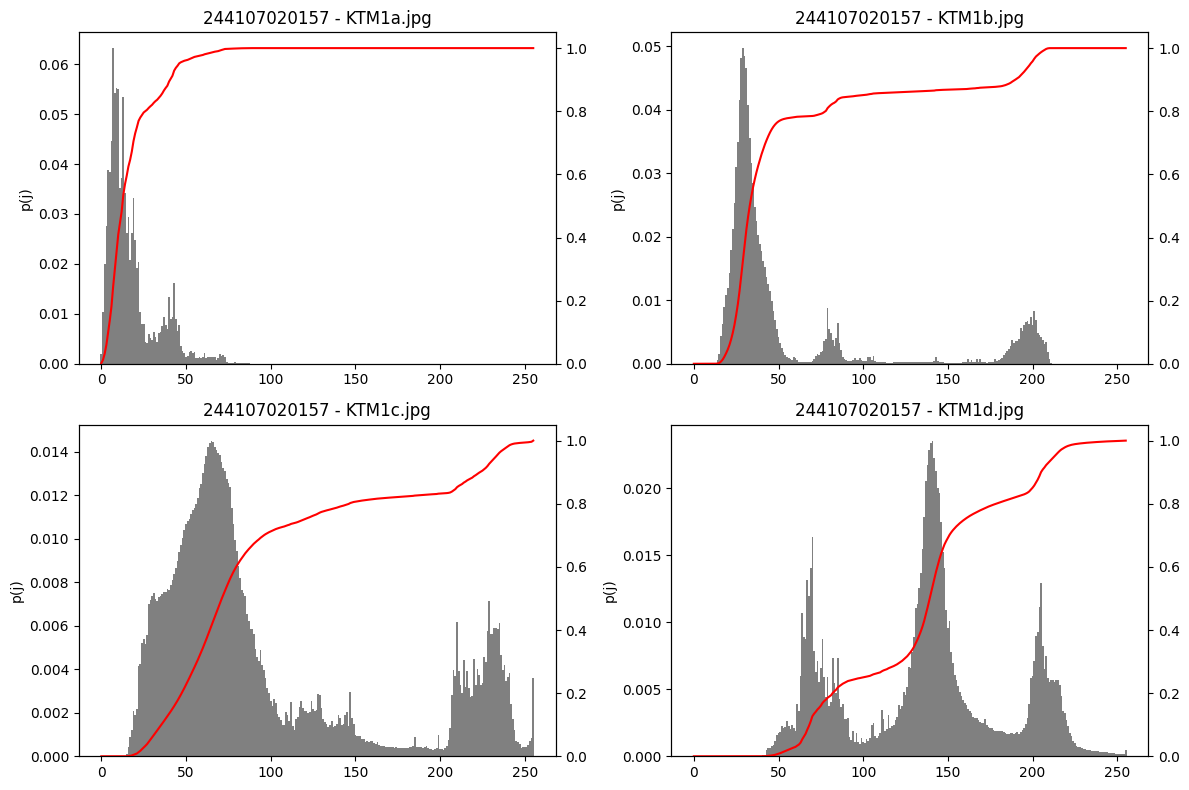

In [20]:
# E1-2
files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig,axs = plt.subplots(2,2, figsize=(12,8))

for ax, f in zip(axs.ravel(), files):
  g = cv.imread(BASE+"/"+f, cv.IMREAD_GRAYSCALE)
  p = np.bincount(g.ravel(), minlength=256) / g.size
  cdf = np.cumsum(p)

  ax.bar(np.arange(256), p, width=1.0, color='gray')
  ax.set_ylabel('p(j)')
  ax2 = ax.twinx()
  ax2.plot(cdf, color='red')
  ax2.set_ylim(0, 1.05)
  ax.set_title(NIM+' - '+f)

plt.tight_layout()
plt.show()

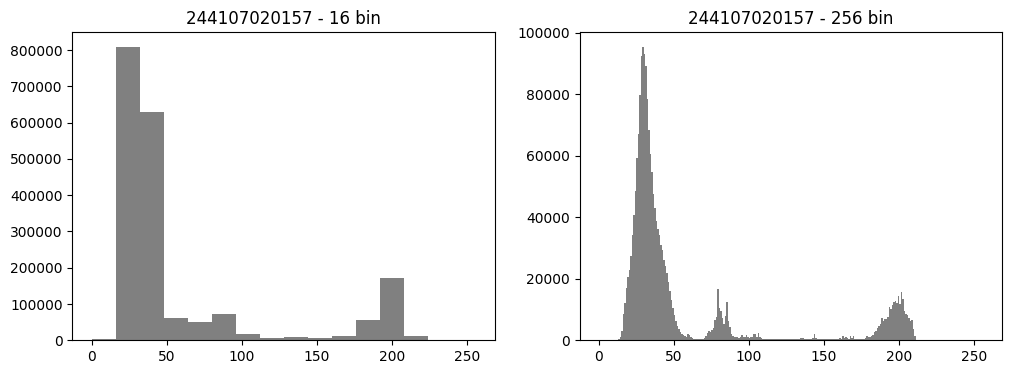

In [29]:
# E1-3
g = cv.imread(BASE+'/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
fig, axs = plt.subplots(1,2, figsize=(12,4))

bins_kecil = int(PARAM['bins'])
for ax, b in zip(axs, [bins_kecil, 256]):
    ax.hist(g.ravel(), bins=b, range=(0, 256), color='gray')
    ax.set_title(f'{NIM} - {b} bin')
plt.show()

/tmp/ipykernel_2706/3609127620.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(gray.ravel(), 256, (0, 256), color='gray'); axs[1, 0].set_title('histogram asli')
/tmp/ipykernel_2706/3609127620.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(eq.ravel(),   256, (0, 256), color='gray'); axs[1, 1].set_title('histogram hasil')


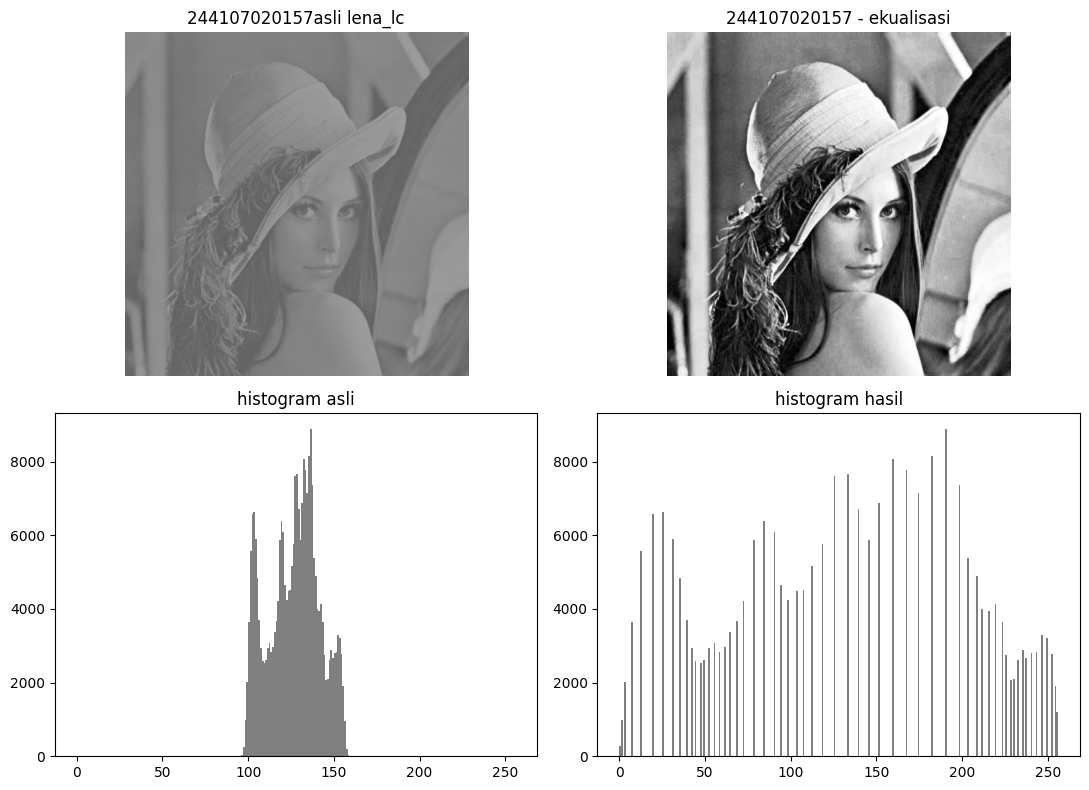

lena_lc | pakai cdf_min = True | selisih maks vs equalizeHist: 0
lena_lc | pakai cdf_min = False | selisih maks vs equalizeHist: 0


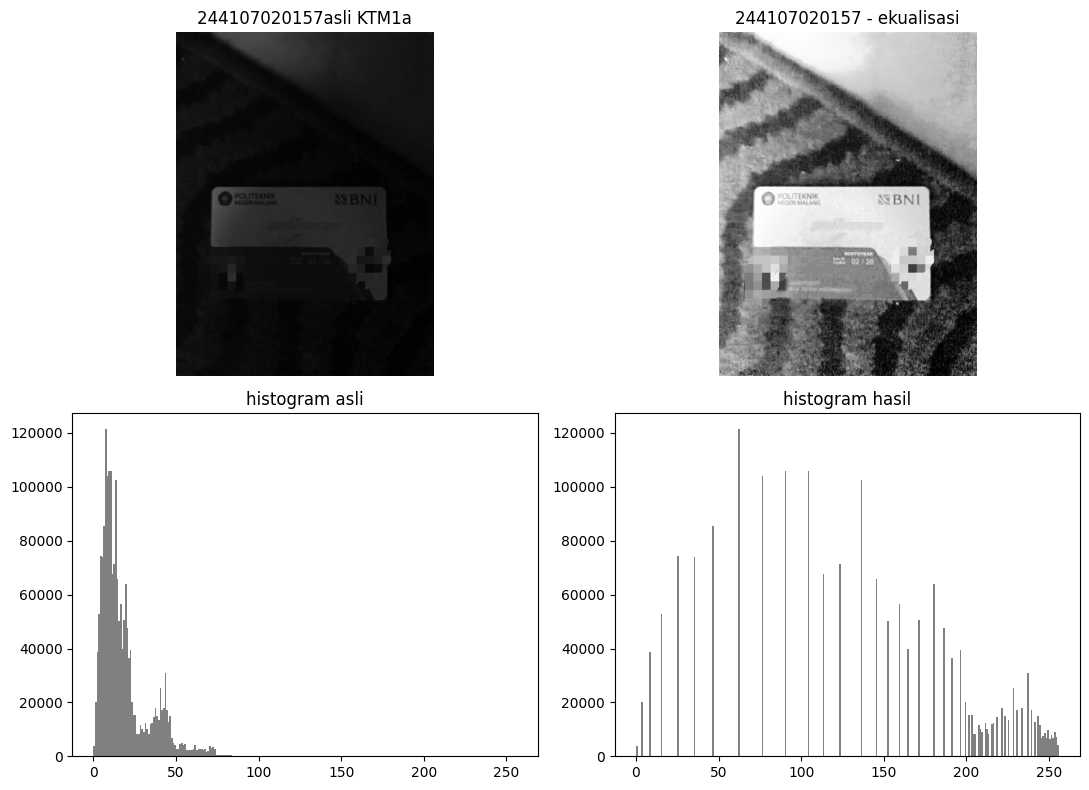

KTM1a | pakai cdf_min = True | selisih maks vs equalizeHist: 0
KTM1a | pakai cdf_min = False | selisih maks vs equalizeHist: 1


In [30]:
# E2-1
def equalize_manual(gray, pakai_cdf_min=True):
  h = np.bincount(gray.ravel(), minlength=256)
  cdf = np.cumsum(h)
  if pakai_cdf_min:
    cdf_min = cdf[cdf > 0][0]
    lut = np.round((cdf - cdf_min) / (gray.size - cdf_min) * 255)
  else:
    lut = np.round(cdf * 255 / gray.size)
  return np.clip(lut, 0, 255).astype(np.uint8)[gray]

def tampilkan(gray, nama):
  eq = equalize_manual(gray)
  fig, axs = plt.subplots(2,2, figsize=(11,8))
  axs[0,0].imshow(gray, cmap='gray', vmin=0, vmax=255); axs[0,0].set_title(NIM+ 'asli '+nama)
  axs[0, 1].imshow(eq,   cmap='gray', vmin=0, vmax=255); axs[0, 1].set_title(NIM + ' - ekualisasi')
  axs[1, 0].hist(gray.ravel(), 256, (0, 256), color='gray'); axs[1, 0].set_title('histogram asli')
  axs[1, 1].hist(eq.ravel(),   256, (0, 256), color='gray'); axs[1, 1].set_title('histogram hasil')
  for a in axs[0]: a.axis('off')
  plt.tight_layout()
  plt.show()

for path, nama in [(CONTOH + '/lena_lc.jpg', 'lena_lc'), (BASE + '/KTM1a.jpg', 'KTM1a')]:
  g = cv.imread(path, cv.IMREAD_GRAYSCALE)
  tampilkan(g, nama)
  for pakai in (True, False):
    d = np.abs(equalize_manual(g, pakai).astype(int) - cv.equalizeHist(g).astype(int)).max()
    print(nama, '| pakai cdf_min =', pakai, '| selisih maks vs equalizeHist:', d)

PSNR asli vs ekualisasi global: 5.96 dB


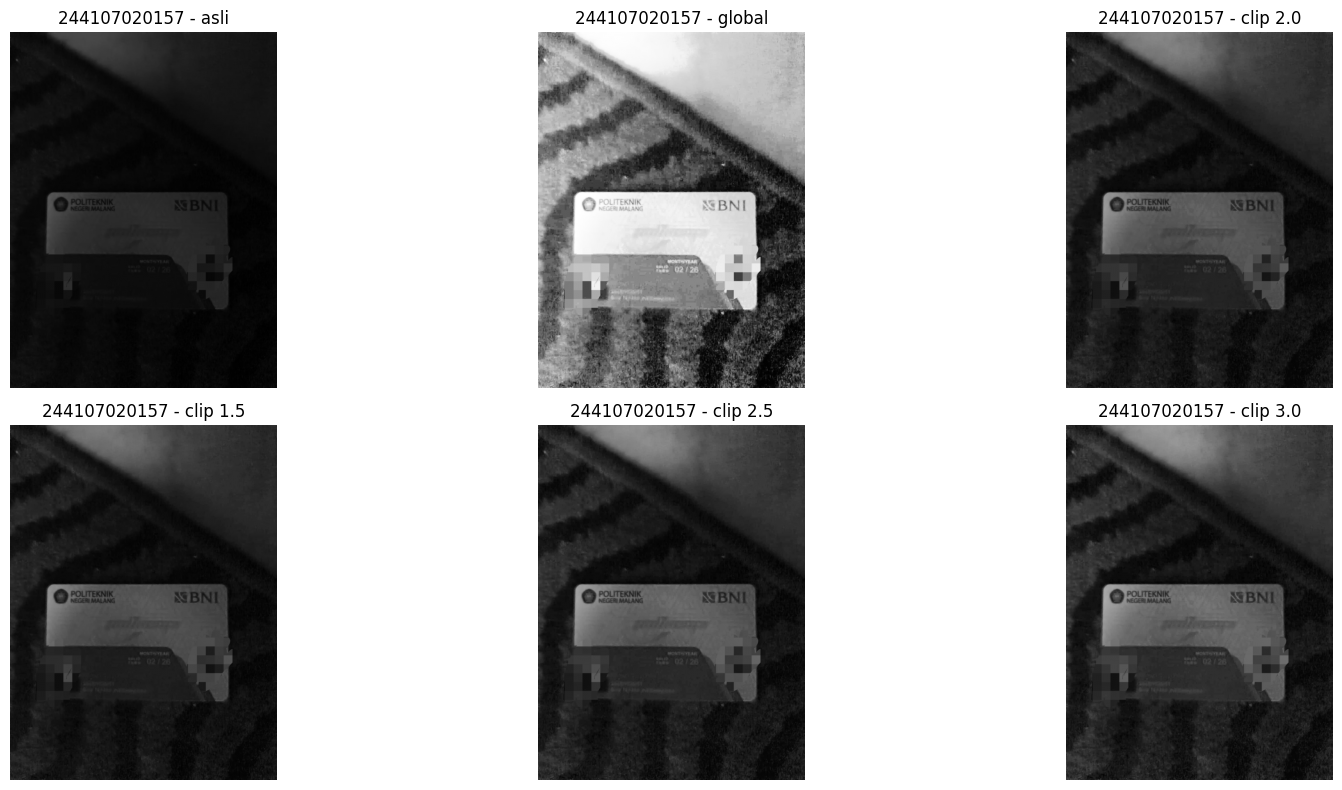

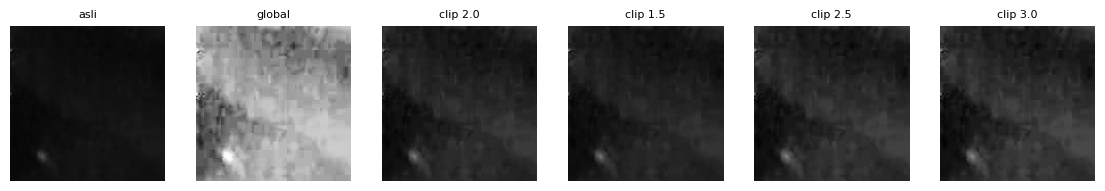

In [31]:
# E2-1c & 2
from cv2.detail import FeatherBlender
def psnr(a, b):
  mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
  return float('inf') if mse == 0 else 10 * np.log10(255 ** 2 / mse)

g = cv.imread(BASE + '/KTM1a.jpg', cv.IMREAD_GRAYSCALE)
eq = cv.equalizeHist(g)
print('PSNR asli vs ekualisasi global:', round(psnr(g, eq), 2), 'dB')

clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
g_cl = clahe.apply(g)

c = PARAM['clip']
kandidat = [max(0.5, c - 0.5), c + 0.5, c + 1.0]
hasil = {f'clip {c}': g_cl}
for k in kandidat:
  hasil[f'clip {k}'] = cv.createCLAHE(clipLimit=k, tileGridSize=(PARAM['tile'],)*2).apply(g)

daftar = [('asli', g), ('global', eq)] + list(hasil.items())
plt.figure(figsize=(18, 8))
for i, (t, im) in enumerate(daftar, 1):
  plt.subplot(2, 3, i)
  plt.imshow(im, cmap='gray', vmin=0, vmax=255)
  plt.title(NIM + ' - ' + t); plt.axis('off')
plt.tight_layout(); plt.show()

y1, y2, x1, x2 = 0, 150, 0, 150
plt.figure(figsize=(14, 3))
for i, (t, im) in enumerate(daftar, 1):
  plt.subplot(1, len(daftar), i)
  plt.imshow(im[y1:y2, x1:x2], cmap='gray', vmin=0, vmax=255)
  plt.title(t, fontsize=8); plt.axis('off')
plt.show()

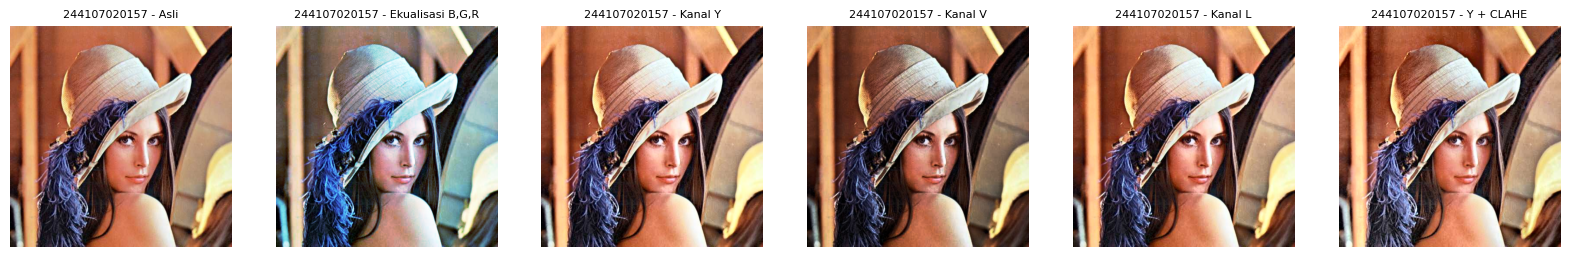

Cara                  geser Hue (der)  rerata terang
Asli                             0.00          122.2
Ekualisasi B,G,R                53.03          127.4
Kanal Y                          0.40          127.9
Kanal V                          0.87          100.6
Kanal L                          1.65          122.7
Y + CLAHE                        0.50          127.2


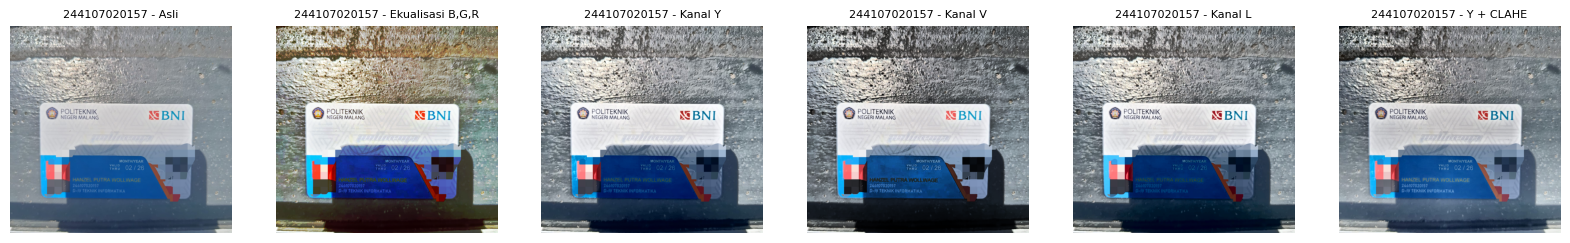

Cara                  geser Hue (der)  rerata terang
Asli                             0.00          136.9
Ekualisasi B,G,R                75.79          128.7
Kanal Y                          1.20          129.6
Kanal V                          3.01          115.9
Kanal L                          5.48          123.0
Y + CLAHE                        0.03          129.7


In [32]:
def geser_hue(asli, hasil):
  h1 = cv.cvtColor(asli,  cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
  d = np.abs(h1 - h2)
  d = np.minimum(d, 180 - d)
  return d.mean()

def uji_warna(berkas):
  bgr = cv.imread(berkas)
  he_rgb = cv.merge([cv.equalizeHist(c) for c in cv.split(bgr)])

  y, cr, cb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb))
  he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

  h, s, v = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2HSV))
  he_v = cv.cvtColor(cv.merge([h, s, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

  l, a, bb = cv.split(cv.cvtColor(bgr, cv.COLOR_BGR2LAB))
  he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, bb]), cv.COLOR_LAB2BGR)

  clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'],)*2)
  he_yc = cv.cvtColor(cv.merge([clahe.apply(y), cr, cb]), cv.COLOR_YCrCb2BGR)

  judul = ['Asli', 'Ekualisasi B,G,R', 'Kanal Y', 'Kanal V', 'Kanal L', 'Y + CLAHE']
  citra = [bgr, he_rgb, he_y, he_v, he_l, he_yc]

  plt.figure(figsize=(20, 4))
  for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 6, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=8); plt.axis('off')
  plt.show()

  print('%-20s %16s %14s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
  for t, c in zip(judul, citra):
    print('%-20s %16.2f %14.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))

uji_warna(CONTOH + '/lena.jpg')
uji_warna(BASE + '/KTM1d.jpg')

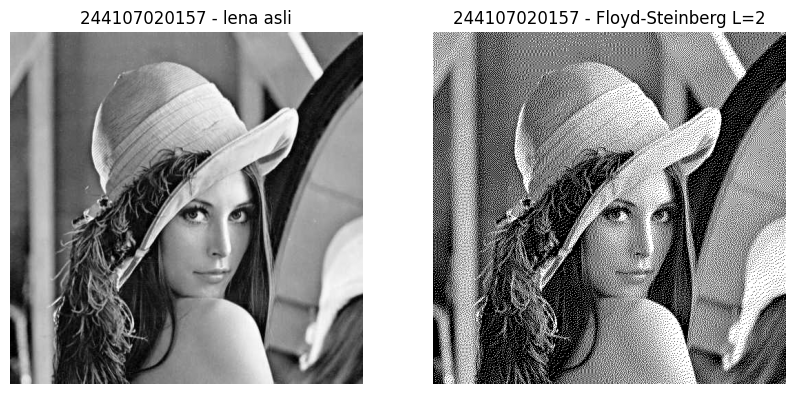

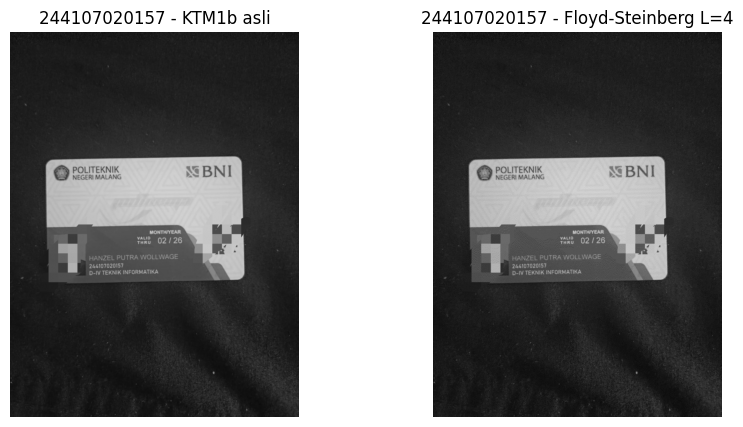

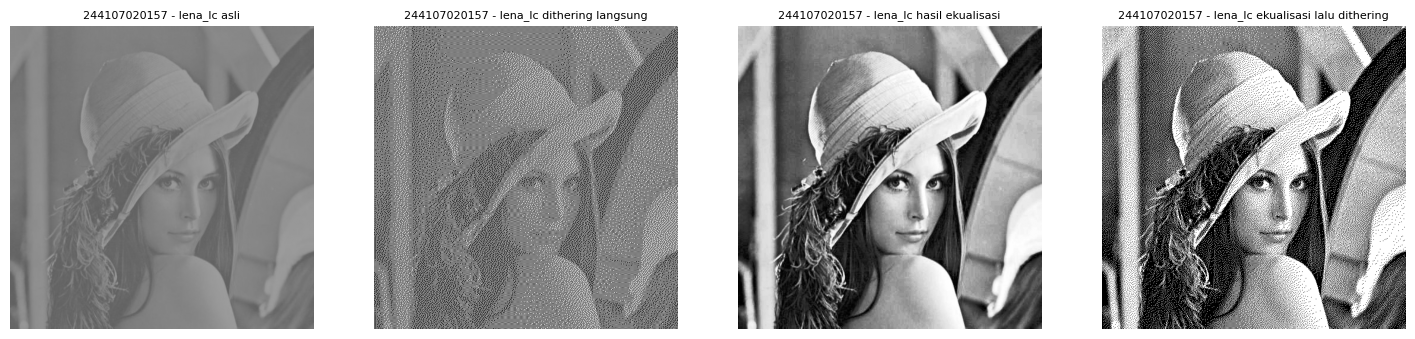

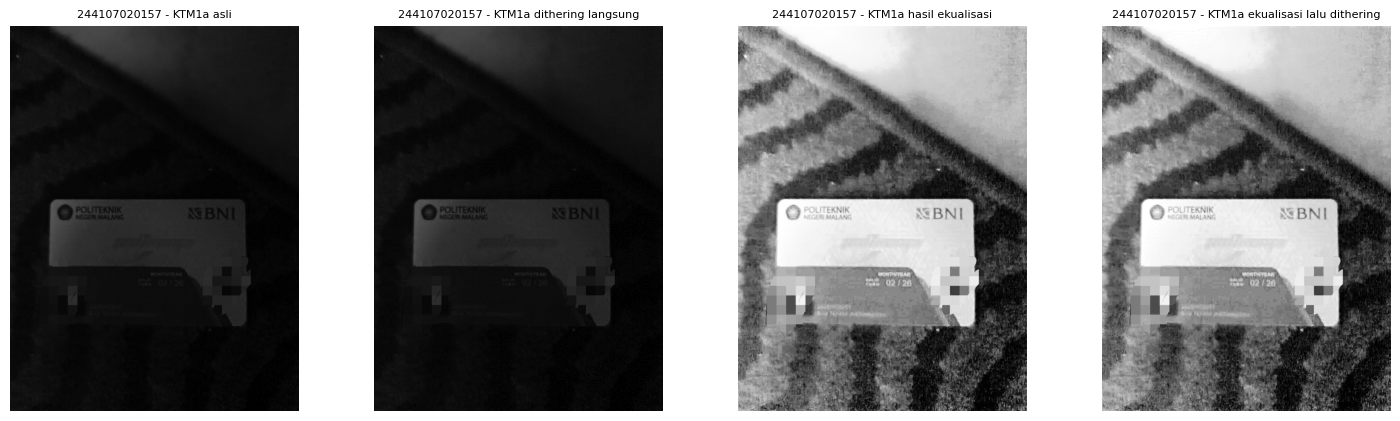

In [34]:
# E3 - Dithering
def floyd_steinberg(gray, L=2):
  img = gray.astype(np.float32).copy()
  step = 255.0 / (L - 1)
  H, W = img.shape
  for y in range(H):
    for x in range(W):
      lama = img[y, x]
      baru = np.round(lama / step) * step
      img[y, x] = baru
      error = lama - baru
      if x + 1 < W:               img[y,   x+1] += error * 7 / 16
      if x > 0 and y + 1 < H:     img[y+1, x-1] += error * 3 / 16
      if y + 1 < H:               img[y+1, x  ] += error * 5 / 16
      if x + 1 < W and y + 1 < H: img[y+1, x+1] += error * 1 / 16
  return np.clip(img, 0, 255).astype(np.uint8)

def dua_gambar(a, b, ta, tb):
  plt.figure(figsize=(10, 5))
  for i, (im, t) in enumerate([(a, ta), (b, tb)], 1):
    plt.subplot(1, 2, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(NIM + ' - ' + t); plt.axis('off')
  plt.show()

g = cv.imread(CONTOH + '/lena.jpg', cv.IMREAD_GRAYSCALE)
dua_gambar(g, floyd_steinberg(g, 2), 'lena asli', 'Floyd-Steinberg L=2')

g = cv.imread(BASE + '/KTM1b.jpg', cv.IMREAD_GRAYSCALE)
dua_gambar(g, floyd_steinberg(g, PARAM['L']), 'KTM1b asli', f"Floyd-Steinberg L={PARAM['L']}")

def urutan(path, nama, L):
  g = cv.imread(path, cv.IMREAD_GRAYSCALE)
  eq = cv.equalizeHist(g)
  daftar = [(g, 'asli'), (floyd_steinberg(g, L), 'dithering langsung'), (eq, 'hasil ekualisasi'), (floyd_steinberg(eq, L), 'ekualisasi lalu dithering')]
  plt.figure(figsize=(18, 5))
  for i, (im, t) in enumerate(daftar, 1):
    plt.subplot(1, 4, i); plt.imshow(im, cmap='gray', vmin=0, vmax=255)
    plt.title(f'{NIM} - {nama} {t}', fontsize=8); plt.axis('off')
  plt.show()

urutan(CONTOH + '/lena_lc.jpg', 'lena_lc', 2)
urutan(BASE + '/KTM1a.jpg', 'KTM1a', PARAM['L'])